# Hybrid Diffusion on MNIST with Fast QFM Encoding

This notebook builds a **hybrid diffusion model** that operates in a fast quantum feature-map (QFM) encoding space.
We:
- encode MNIST pixels with a light-weight QFM (sin/cos),
- train a diffusion model in the encoded space,
- decode back to classical pixels.

The encoding is *fast* (pure trigonometry), yet mimics a simple quantum feature map, making it a good first step
before heavier quantum circuits.


In [91]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model
Device: cpu


## 1. Load MNIST
We keep MNIST in `[0,1]` range for encoding. If the dataset is missing, set `download=True`.


In [92]:
data_root = 'mnist'
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root=data_root, train=True, download=False, transform=transform)
val_ds = datasets.MNIST(root=data_root, train=False, download=False, transform=transform)

# Use smaller subsets for quick iteration
train_n = 20000
val_n = 2000

def subset_tensor(ds, n):
    xs = []
    for i in range(n):
        x, _ = ds[i]
        xs.append(x)  # (1, 28, 28)
    return torch.stack(xs)

train_x = subset_tensor(train_ds, train_n)
val_x = subset_tensor(val_ds, val_n)

print('Train:', train_x.shape, 'Val:', val_x.shape)


Train: torch.Size([20000, 1, 28, 28]) Val: torch.Size([2000, 1, 28, 28])


## 2. Fast QFM Encoding + Decoding
We map each pixel `x in [0,1]` to a 2D feature on the unit circle:
`phi(x) = (sin(pi*x), cos(pi*x))`.

We optionally add **entangled features** by mixing each pixel with its right/down neighbors,
adding two extra channels. This keeps decoding stable (channels 0-1) while adding a lightweight
correlation signal.


In [93]:
use_entangled_features = True
entangle_alpha = 0.5  # strength of neighbor mixing (0 disables entanglement)

def qfm_encode(x, entangle=use_entangled_features):
    # x: (N, 1, H, W) in [0,1]
    angle = math.pi * x
    sin = torch.sin(angle)
    cos = torch.cos(angle)

    if not entangle:
        return torch.cat([sin, cos], dim=1)  # (N, 2, H, W)

    # Neighbor-mixed feature (entanglement proxy)
    x_r = F.pad(x, (0, 1, 0, 0))[:, :, :, 1:]  # right neighbor, zero-padded
    x_d = F.pad(x, (0, 0, 0, 1))[:, :, 1:, :]  # down neighbor, zero-padded
    mixed = (1.0 - entangle_alpha) * x + 0.5 * entangle_alpha * (x_r + x_d)

    angle_e = math.pi * mixed
    sin_e = torch.sin(angle_e)
    cos_e = torch.cos(angle_e)

    return torch.cat([sin, cos, sin_e, cos_e], dim=1)  # (N, 4, H, W)

def project_to_circle(z):
    # Project only the base channels (0,1) to unit circle; keep extras if present
    base = z[:, :2]
    sin = base[:, 0:1]
    cos = base[:, 1:2]
    norm = torch.sqrt(sin ** 2 + cos ** 2 + 1e-8)
    sin = sin / norm
    cos = cos / norm
    base_proj = torch.cat([sin, cos], dim=1)
    if z.shape[1] > 2:
        return torch.cat([base_proj, z[:, 2:]], dim=1)
    return base_proj

def qfm_decode(z):
    # z: (N, C, H, W) -> (N, 1, H, W) in [0,1]; decode from base channels
    z = z[:, :2]
    z = project_to_circle(z)
    sin = z[:, 0:1]
    cos = z[:, 1:2]
    angle = torch.atan2(sin, cos)
    angle = torch.where(angle < 0, angle + 2 * math.pi, angle)
    angle = torch.clamp(angle, 0.0, math.pi)
    x = angle / math.pi
    return x

qfm_channels = 4 if use_entangled_features else 2
print('QFM channels:', qfm_channels)

# Quick round-trip sanity check
with torch.no_grad():
    test = train_x[:8].to(device)
    enc = qfm_encode(test)
    dec = qfm_decode(enc)
    print('Encoded:', enc.shape, 'Decoded:', dec.shape)


QFM channels: 4
Encoded: torch.Size([8, 4, 28, 28]) Decoded: torch.Size([8, 1, 28, 28])


### Visual sanity check


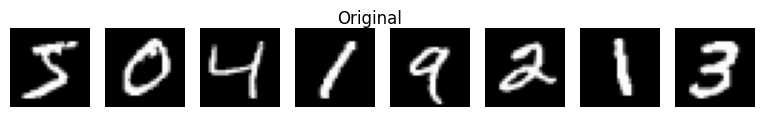

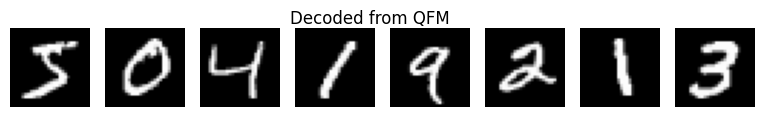

In [94]:
def show_grid(x, n=8, title=''):
    x = x[:n].detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n * 1.2, 1.2))
    for i in range(n):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

with torch.no_grad():
    show_grid(test, title='Original')
    show_grid(dec, title='Decoded from QFM')


## 3. Diffusion Utilities (DDPM-style)
We run diffusion in **encoded space**. The model can predict either noise (epsilon) or x0.


In [95]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, timesteps)

T = 200  # reduce for faster iteration
betas = linear_beta_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    # a: (T,), t: (N,), return (N,1,1,1) broadcastable
    out = a.gather(-1, t).float()
    return out.view(-1, 1, 1, 1)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_ac * x0 + sqrt_om * noise

def predict_x0_from_noise(x_t, t, noise):
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    return (x_t - sqrt_om * noise) / sqrt_ac

def predict_eps_from_x0(x_t, t, x0):
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    return (x_t - sqrt_ac * x0) / sqrt_om


## 4. Time-Conditional U-Net (small)
A light U-Net is enough to demonstrate the hybrid pipeline.


In [96]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x, t_emb):
        h = self.conv(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        return h, self.pool(h)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = DoubleConv(out_ch * 2, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = x + self.time_proj(t_emb)[:, :, None, None]
        return x

class TimeEmbedding(nn.Module):
    def __init__(self, n_steps, time_dim):
        super().__init__()
        self.embedding = nn.Embedding(n_steps, time_dim)
        self.mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
        )
    def forward(self, t):
        return self.mlp(self.embedding(t))

class SimpleUNet(nn.Module):
    def __init__(self, in_channels, out_channels=None, base=32, time_dim=128, n_steps=200):
        super().__init__()
        if out_channels is None:
            out_channels = in_channels
        self.time_emb = TimeEmbedding(n_steps, time_dim)
        self.down1 = Down(in_channels, base, time_dim)
        self.down2 = Down(base, base * 2, time_dim)
        self.bot = DoubleConv(base * 2, base * 4)
        self.up2 = Up(base * 4, base * 2, time_dim)
        self.up1 = Up(base * 2, base, time_dim)
        self.out = nn.Conv2d(base, out_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h1, x = self.down1(x, t_emb)
        h2, x = self.down2(x, t_emb)
        x = self.bot(x)
        x = self.up2(x, h2, t_emb)
        x = self.up1(x, h1, t_emb)
        return self.out(x)


## 5. Prepare Encoded Datasets
We encode MNIST once, then train in QFM space.


In [97]:
with torch.no_grad():
    encoded_train = qfm_encode(train_x)
    encoded_val = qfm_encode(val_x)

train_loader = DataLoader(TensorDataset(encoded_train, train_x), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(encoded_val, val_x), batch_size=128, shuffle=False)

print('Encoded train:', encoded_train.shape)


Encoded train: torch.Size([20000, 4, 28, 28])


## 6. Hybrid Diffusion in QFM Space (x0 prediction)
The model predicts **x0** (clean QFM encoding) from noisy QFM inputs.
We also include pixel-space consistency loss to improve raw decoded output.


In [98]:
model_qfm = SimpleUNet(in_channels=qfm_channels, out_channels=qfm_channels, base=32, time_dim=128, n_steps=T).to(device)
opt = torch.optim.Adam(model_qfm.parameters(), lr=2e-4)

use_circle_loss = True
circle_weight = 0.4

use_pixel_loss = True
pixel_weight = 0.2

# Heavier weight on base sin/cos channels (0-1)
base_channel_weight = 2.0
extra_channel_weight = 1.0

def train_epoch_qfm(model, loader):
    model.train()
    losses = []
    for (x_enc, x_px) in loader:
        x_enc = x_enc.to(device)
        x_px = x_px.to(device)
        t = torch.randint(0, T, (x_enc.shape[0],), device=device)
        noise = torch.randn_like(x_enc)
        x_t = q_sample(x_enc, t, noise)

        pred_x0 = model(x_t, t)
        mse = (pred_x0 - x_enc) ** 2
        if pred_x0.shape[1] > 2:
            loss_base = mse[:, :2].mean()
            loss_extra = mse[:, 2:].mean()
            loss = base_channel_weight * loss_base + extra_channel_weight * loss_extra
        else:
            loss = mse.mean()

        if use_circle_loss:
            base = pred_x0[:, :2]
            sin = base[:, 0:1]
            cos = base[:, 1:2]
            norm = torch.sqrt(sin ** 2 + cos ** 2 + 1e-8)
            circle_loss = torch.mean((norm - 1.0) ** 2)
            loss = loss + circle_weight * circle_loss

        if use_pixel_loss:
            x0_proj = project_to_circle(pred_x0)
            x_px_hat = qfm_decode(x0_proj)
            pixel_loss = F.mse_loss(x_px_hat, x_px)
            loss = loss + pixel_weight * pixel_loss

        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return float(np.mean(losses))

# Example quick training loop (adjust epochs as needed)
epochs = 3
for e in range(1, epochs + 1):
    loss = train_epoch_qfm(model_qfm, train_loader)
    print(f'Epoch {e} - loss: {loss:.4f}')


Epoch 1 - loss: 0.3679
Epoch 2 - loss: 0.1831
Epoch 3 - loss: 0.1659


## 7. Sampling in QFM Space + Decoding (x0 prediction)
Generate images by sampling in QFM space, then decode back to pixels.


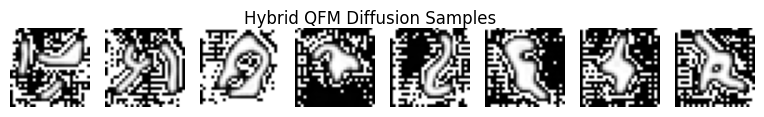

In [99]:
@torch.no_grad()
def p_sample(model, x, t, mode='eps', project=False):
    betas_t = extract(betas, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)

    if mode == 'x0':
        x0_hat = model(x, t)
        if project:
            x0_hat = project_to_circle(x0_hat)
        eps = predict_eps_from_x0(x, t, x0_hat)
    else:
        eps = model(x, t)

    # DDPM mean
    model_mean = sqrt_recip_alphas_t * (x - betas_t * eps / sqrt_om)
    if (t == 0).all():
        return model_mean
    noise = torch.randn_like(x)
    var = extract(posterior_variance, t, x.shape)
    return model_mean + torch.sqrt(var) * noise

@torch.no_grad()
def p_sample_loop(model, shape, mode='eps', project=False):
    x = torch.randn(shape, device=device)
    for i in reversed(range(T)):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, mode=mode, project=project)
    return x

# Sample encoded images and decode
samples_qfm = p_sample_loop(model_qfm, (16, qfm_channels, 28, 28), mode='x0', project=True)
samples_img = qfm_decode(samples_qfm)

show_grid(samples_img, n=8, title='Hybrid QFM Diffusion Samples')


## 8. Baseline: Classical Diffusion (Pixel Space, epsilon prediction)
Standard pixel-space diffusion model.


Pixel Epoch 1 - loss: 0.2286
Pixel Epoch 2 - loss: 0.0853
Pixel Epoch 3 - loss: 0.0663


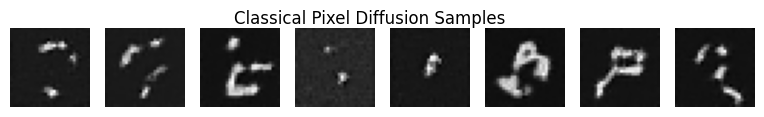

In [100]:
model_px = SimpleUNet(in_channels=1, out_channels=1, base=32, time_dim=128, n_steps=T).to(device)
opt_px = torch.optim.Adam(model_px.parameters(), lr=2e-4)

train_loader_px = DataLoader(TensorDataset(train_x), batch_size=128, shuffle=True)

def train_epoch_px(model, loader):
    model.train()
    losses = []
    for (x,) in loader:
        x = x.to(device)
        t = torch.randint(0, T, (x.shape[0],), device=device)
        noise = torch.randn_like(x)
        x_t = q_sample(x, t, noise)
        pred = model(x_t, t)
        loss = F.mse_loss(pred, noise)
        opt_px.zero_grad()
        loss.backward()
        opt_px.step()
        losses.append(loss.item())
    return float(np.mean(losses))

epochs = 3
for e in range(1, epochs + 1):
    loss = train_epoch_px(model_px, train_loader_px)
    print(f'Pixel Epoch {e} - loss: {loss:.4f}')

# Sample pixel-space diffusion
samples_px = p_sample_loop(model_px, (16, 1, 28, 28), mode='eps', project=False)
show_grid(samples_px, n=8, title='Classical Pixel Diffusion Samples')


## 9. Hybrid Conditioning: QFM-Conditioned Pixel Diffusion (Option 3)
We keep diffusion **in pixel space**, but condition the denoiser on QFM features.
This avoids decoding during sampling and is more robust for non-MNIST datasets.


QFM-Cond Epoch 1 - loss: 0.1660
QFM-Cond Epoch 2 - loss: 0.0301
QFM-Cond Epoch 3 - loss: 0.0194


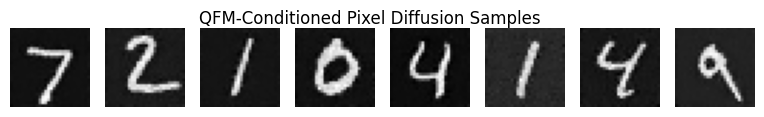

In [101]:
model_px_qfm = SimpleUNet(in_channels=1 + qfm_channels, out_channels=1, base=32, time_dim=128, n_steps=T).to(device)
opt_px_qfm = torch.optim.Adam(model_px_qfm.parameters(), lr=2e-4)

train_loader_px_qfm = DataLoader(TensorDataset(train_x, encoded_train), batch_size=128, shuffle=True)

def train_epoch_px_qfm(model, loader):
    model.train()
    losses = []
    for (x_px, x_qfm) in loader:
        x_px = x_px.to(device)
        x_qfm = x_qfm.to(device)
        t = torch.randint(0, T, (x_px.shape[0],), device=device)
        noise = torch.randn_like(x_px)
        x_t = q_sample(x_px, t, noise)
        model_in = torch.cat([x_t, x_qfm], dim=1)
        pred = model(model_in, t)
        loss = F.mse_loss(pred, noise)
        opt_px_qfm.zero_grad()
        loss.backward()
        opt_px_qfm.step()
        losses.append(loss.item())
    return float(np.mean(losses))

epochs = 3
for e in range(1, epochs + 1):
    loss = train_epoch_px_qfm(model_px_qfm, train_loader_px_qfm)
    print(f'QFM-Cond Epoch {e} - loss: {loss:.4f}')

@torch.no_grad()
def p_sample_cond(model, x, t, qfm_feat):
    betas_t = extract(betas, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    pred = model(torch.cat([x, qfm_feat], dim=1), t)
    model_mean = sqrt_recip_alphas_t * (x - betas_t * pred / sqrt_om)
    if (t == 0).all():
        return model_mean
    noise = torch.randn_like(x)
    var = extract(posterior_variance, t, x.shape)
    return model_mean + torch.sqrt(var) * noise

@torch.no_grad()
def p_sample_loop_cond(model, qfm_feat):
    x = torch.randn((qfm_feat.shape[0], 1, 28, 28), device=device)
    for i in reversed(range(T)):
        t = torch.full((x.shape[0],), i, device=device, dtype=torch.long)
        x = p_sample_cond(model, x, t, qfm_feat)
    return x

# Conditional samples using QFM from validation images
qfm_cond = encoded_val[:16].to(device)
samples_px_qfm = p_sample_loop_cond(model_px_qfm, qfm_cond)
show_grid(samples_px_qfm, n=8, title='QFM-Conditioned Pixel Diffusion Samples')


## 10. Quick Denoising Comparison (One-Step)
We compare reconstruction quality from a noisy step for QFM, pixel, and QFM-conditioned models.


One-step MSE - QFM: 0.4159000813961029 Pixel: 0.029138891026377678 QFM-Cond: 0.004516092594712973


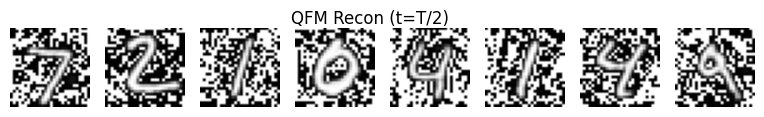

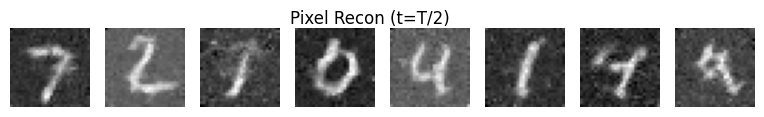

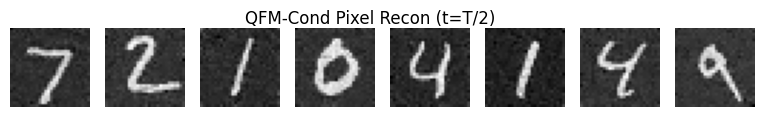

In [102]:
@torch.no_grad()
def one_step_recon_eps(model, x0):
    t = torch.full((x0.shape[0],), T // 2, device=device, dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    pred_noise = model(x_t, t)
    x0_hat = predict_x0_from_noise(x_t, t, pred_noise)
    return x0_hat

@torch.no_grad()
def one_step_recon_qfm_x0(model, x0_qfm):
    t = torch.full((x0_qfm.shape[0],), T // 2, device=device, dtype=torch.long)
    noise = torch.randn_like(x0_qfm)
    x_t = q_sample(x0_qfm, t, noise)
    x0_hat = model(x_t, t)
    x0_hat = project_to_circle(x0_hat)
    return x0_hat

@torch.no_grad()
def one_step_recon_cond(model, x0_px, qfm_feat):
    t = torch.full((x0_px.shape[0],), T // 2, device=device, dtype=torch.long)
    noise = torch.randn_like(x0_px)
    x_t = q_sample(x0_px, t, noise)
    pred_noise = model(torch.cat([x_t, qfm_feat], dim=1), t)
    x0_hat = predict_x0_from_noise(x_t, t, pred_noise)
    return x0_hat

val_batch = val_x[:64].to(device)
val_enc = qfm_encode(val_batch)

# QFM x0-pred reconstruction
rec_enc = one_step_recon_qfm_x0(model_qfm, val_enc)
rec_img = qfm_decode(rec_enc)

# Pixel baseline reconstruction
rec_px = one_step_recon_eps(model_px, val_batch)

# QFM-conditioned pixel reconstruction
rec_px_qfm = one_step_recon_cond(model_px_qfm, val_batch, val_enc)

mse_qfm = F.mse_loss(rec_img, val_batch).item()
mse_px = F.mse_loss(rec_px, val_batch).item()
mse_px_qfm = F.mse_loss(rec_px_qfm, val_batch).item()

print('One-step MSE - QFM:', mse_qfm, 'Pixel:', mse_px, 'QFM-Cond:', mse_px_qfm)
show_grid(rec_img, n=8, title='QFM Recon (t=T/2)')
show_grid(rec_px, n=8, title='Pixel Recon (t=T/2)')
show_grid(rec_px_qfm, n=8, title='QFM-Cond Pixel Recon (t=T/2)')


## 11. Mask out background before numeric evals
We build a digit mask from the real image and apply it to reconstructions.


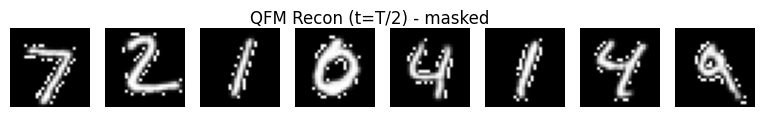

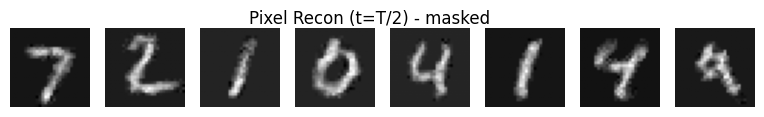

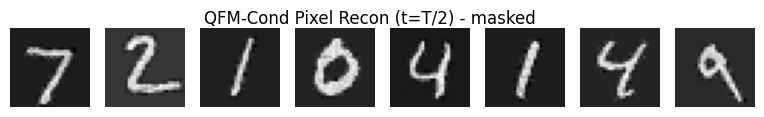

In [103]:
mask_thresh = 0.2  # MNIST digit threshold
mask_dilate = 1    # dilation radius (pixels)

def make_digit_mask(x, thresh=0.2, dilate=1):
    # x: (N, 1, H, W) in [0,1]
    mask = (x > thresh).float()
    if dilate > 0:
        # dilation using max-pool
        mask = F.max_pool2d(mask, kernel_size=2*dilate+1, stride=1, padding=dilate)
    return mask

digit_mask = make_digit_mask(val_batch, mask_thresh, mask_dilate)

real_masked = val_batch * digit_mask
rec_img_masked = rec_img * digit_mask
rec_px_masked = rec_px * digit_mask
rec_px_qfm_masked = rec_px_qfm * digit_mask

# Replot masked reconstructions
show_grid(rec_img_masked, n=8, title='QFM Recon (t=T/2) - masked')
show_grid(rec_px_masked, n=8, title='Pixel Recon (t=T/2) - masked')
show_grid(rec_px_qfm_masked, n=8, title='QFM-Cond Pixel Recon (t=T/2) - masked')


## 12. Numeric Comparison (FID-like / SSIM / Wasserstein)
These are *pixel-space* comparisons on the reconstructions. The FID here is computed on raw pixels (not Inception),
so treat it as a relative heuristic rather than a standard FID.


In [104]:
from utils.statistics import calculate_statistics, calculate_fid_stable, calculate_wasserstein
from skimage.metrics import structural_similarity as ssim

def to_np(x):
    return x.detach().cpu().numpy()

real = to_np(real_masked).squeeze(1)
qfm = to_np(rec_img_masked).squeeze(1)
px = to_np(rec_px_masked).squeeze(1)
px_qfm = to_np(rec_px_qfm_masked).squeeze(1)

# FID-like on raw pixels
mu_r, sig_r = calculate_statistics(real)
mu_q, sig_q = calculate_statistics(qfm)
mu_p, sig_p = calculate_statistics(px)
mu_c, sig_c = calculate_statistics(px_qfm)
fid_qfm = calculate_fid_stable(mu_r, sig_r, mu_q, sig_q)
fid_px = calculate_fid_stable(mu_r, sig_r, mu_p, sig_p)
fid_px_qfm = calculate_fid_stable(mu_r, sig_r, mu_c, sig_c)

# SSIM (mean over batch)
ssim_qfm = float(np.mean([ssim(real[i], qfm[i], data_range=1.0) for i in range(real.shape[0])]))
ssim_px = float(np.mean([ssim(real[i], px[i], data_range=1.0) for i in range(real.shape[0])]))
ssim_px_qfm = float(np.mean([ssim(real[i], px_qfm[i], data_range=1.0) for i in range(real.shape[0])]))

# Wasserstein distance (mean over batch)
w_qfm = calculate_wasserstein(real, qfm)
w_px = calculate_wasserstein(real, px)
w_px_qfm = calculate_wasserstein(real, px_qfm)

print('FID-like (lower better):  QFM', fid_qfm, 'Pixel', fid_px, 'QFM-Cond', fid_px_qfm)
print('SSIM (higher better):    QFM', ssim_qfm, 'Pixel', ssim_px, 'QFM-Cond', ssim_px_qfm)
print('Wasserstein (lower):     QFM', w_qfm, 'Pixel', w_px, 'QFM-Cond', w_px_qfm)


FID-like (lower better):  QFM 27.57630706928235 Pixel 13.843335813637594 QFM-Cond 1.4614138853660705
SSIM (higher better):    QFM 0.6672707145517409 Pixel 0.7173136813737346 QFM-Cond 0.9476818474887738
Wasserstein (lower):     QFM 0.03393340366917291 Pixel 0.03984817976916805 QFM-Cond 0.012967982757851916
